# Network MultiAgent System

In [1]:
!pip install langgraph langsmith langchain_classic langchain_community langchain_groq langchain_core pydantic chromadb langchain-tavily langchain_huggingface youtube_search wikipedia httpx langchain_google_genai streamlit transformers yfinance langchain_openrouter typing-extensions langchain-text-splitters

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [2]:
import os
from google.colab import userdata
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY').strip()

os.environ["TAVILY_API_KEY"]= userdata.get("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"]= userdata.get("SERPER_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [15]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="llama-3.3-70b-versatile")

# from langchain_openrouter import ChatOpenRouter

# llm = ChatOpenRouter(
#     model="openrouter/free",
# )

In [5]:
!pip install langchain-experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 8.8 MB/s eta 0:00:00


In [6]:
from typing_extensions import Literal
from langchain_core.tools import tool
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.types import Command
from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from typing import Annotated
from langchain_experimental.utilities import PythonREPL

/tmp/ipykernel_843/2818063718.py:9: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


In [16]:
groq_model = llm

In [17]:
groq_model.invoke("hi").content

"It's nice to meet you. Is there something I can help you with, or would you like to chat?"

In [13]:
or_model = llm

In [14]:
or_model.invoke("hi").content

'\nHello! How can I help you today?\n'

In [18]:
def add_numbers(state):
  result = state["num1"]+state["num2"]
  print(f"addtional result: {result}")
  return Command(goto="multiply", update={"sum": result})

In [19]:
state = {"num1": 1, "num2": 2}

In [20]:
add_numbers(state)

addtional result: 3


Command(update={'sum': 3}, goto='multiply')

In [45]:
import operator

@tool
def transfer_to_multiplication_expert(num1: float, num2: float):
  """Ask multiplication agent for help with multiplying two numbers.
  Args:
    num1: The first number to multiply.
    num2: The second number to multiply.
  """
  return

In [46]:
@tool
def transfer_to_addition_expert(num1: float, num2: float):
  """Ask addition agent for help with adding two numbers.
  Args:
    num1: The first number to add.
    num2: The second number to add.
  """
  return

In [47]:
model_with_tool = groq_model.bind_tools([transfer_to_multiplication_expert])

In [48]:
ai_message = model_with_tool.invoke("How are you?")

In [49]:
ai_message.tool_calls

[]

In [50]:
ai_message = model_with_tool.invoke("what's (3 + 5) * 12. Provide me the output")

In [51]:
ai_message.tool_calls

[{'name': 'transfer_to_multiplication_expert',
  'args': {'num1': 8, 'num2': 12},
  'id': '8pqnqrjex',
  'type': 'tool_call'}]

In [52]:
def additional_expert(state: MessagesState) -> Command[Literal["multiplication_expert", "__end__"]]:

  system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

  messages = [{"role": "system", "content": system_prompt}] + state["messages"]


  ai_msg = groq_model.bind_tools([transfer_to_multiplication_expert]).invoke(messages)

  if len(ai_msg.tool_calls) > 0:
    tool_call_id = ai_msg.tool_calls[-1]["id"]
    tool_msg = {
        "role": "tool",
        "content": "Successfully transferred",
        "tool_call_id": tool_call_id,
    }

    return Command( goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]})

  return {"messages": [ai_msg]}

In [53]:
def multiplication_expert(state: MessagesState) -> Command[Literal["additional_expert", "__end__"]]:

  system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )

  messages = [{"role": "system", "content": system_prompt}] + state["messages"]

  ai_msg = groq_model.bind_tools([transfer_to_addition_expert]).invoke(messages)

  if len(ai_msg.tool_calls) > 0:
    tool_call_id = ai_msg.tool_calls[-1]["id"]
    tool_msg = {
        "role": "tool",
        "content": "Successfully transferred",
        "tool_call_id": tool_call_id,
    }

    return Command( goto="additional_expert", update={"messages": [ai_msg, tool_msg]})

  return {"messages": [ai_msg]}


In [54]:
graph = StateGraph(MessagesState)

In [55]:
graph.add_node("additional_expert", additional_expert)
graph.add_node("multiplication_expert", multiplication_expert)

In [56]:
graph.add_edge(START, "additional_expert")

In [57]:
app = graph.compile()

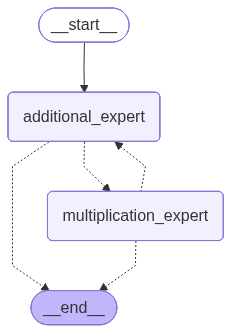

In [58]:
display(Image(app.get_graph().draw_mermaid_png()))

In [59]:
app.invoke({"messages": [("user", "what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='8b7b218d-8c2e-4b18-94d3-9d70424d7cb3'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '8a2cn3gmg', 'function': {'arguments': '{"num1":8,"num2":12}', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 331, 'total_tokens': 354, 'completion_time': 0.040569454, 'completion_tokens_details': None, 'prompt_time': 0.016412262, 'prompt_tokens_details': None, 'queue_time': 0.00833761, 'total_time': 0.056981716}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9b9a-8e62-7373-9275-43a842a009f5-0', tool_calls=[{'name': 'transfer_to_multiplication_expert', 'args': {'num1': 8, 'num2': 12}, 'id': '8a2cn3gmg', 'ty

In [60]:
from langchain_core.messages import convert_to_messages

def pretty_print_messsages(update):
  if isinstance(update, tuple):
    ns, update = update
    # skip parent graph updates in the printouts
    if len(ns) == 0:
      return

    graph_id = ns[-1].split(":")[0]
    print(f"Update from subgraph {graph_id}:")
    print("\n")

  for node_name, node_update in update.items():
    print(f"Update from node {node_name}:")
    print("\n")

    for m in convert_to_messages(node_update["messages"]):
      m.pretty_print()
    print("\n")

In [61]:
# Let's run the graph with an expression that requires both addition and multiplication:
for chunk in app.stream(
  {"messages": [("user",  "what's (3 + 5) * 12. Provide me the output")]}

  ):

  print("****chunk...****")

  pretty_print_messsages(chunk)

****chunk...****
Update from node additional_expert:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_multiplication_expert (2ex255hb2)
 Call ID: 2ex255hb2
  Args:
    num1: 8
    num2: 12
================================= Tool Message =================================

Successfully transferred


****chunk...****
Update from node multiplication_expert:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_addition_expert (abmk2n96a)
 Call ID: abmk2n96a
  Args:
    num1: 3
    num2: 5
================================= Tool Message =================================

Successfully transferred


****chunk...****
Update from node additional_expert:


================================== Ai Message ==================================

The calculation (3 + 5) equals 8. Then, 8 * 12 equals 96. The answer is 96.




In [62]:
@tool
def transfer_to_travel_advisor():
  """Ask travel advisor for help."""
  return

@tool
def transfer_to_hotel_advisor():
  """Ask hotel advisor for help."""
  return

In [63]:
def travel_advisor(state: MessagesState) -> Command[Literal["hotel_advisor", "__end__"]]:
  system_prompt = (
        "You are a general travel expert that can recommend travel destinations (e.g. countries, cities, etc). "
        "If you need hotel recommendations, ask 'hotel_advisor' for help."
    )

  messages = [{"role": "system", "content": system_prompt}] + state["messages"]

  ai_msg = groq_model.bind_tools([transfer_to_hotel_advisor]).invoke(messages)

  if len(ai_msg.tool_calls) > 0:
    tool_call_id = ai_msg.tool_calls[-1]["id"]
    tool_msg = {
        "role": "tool",
        "content": "Successfully transferred",
        "tool_call_id": tool_call_id,
    }

    return Command( goto="hotel_advisor", update={"messages": [ai_msg, tool_msg]})

  return {"messages": [ai_msg]}


In [64]:
def hotel_advisor(state: MessagesState) -> Command[Literal["travel_advisor", "__end__"]]:
  system_prompt = (
        "You are a hotel expert that can provide hotel recommendations for a given destination. "
        "If you need help picking travel destinations, ask 'travel_advisor' for help."
    )

  messages = [{"role": "system", "content": system_prompt}] + state["messages"]

  ai_msg = groq_model.bind_tools([transfer_to_travel_advisor]).invoke(messages)

  if len(ai_msg.tool_calls) > 0:
    tool_call_id = ai_msg.tool_calls[-1]["id"]
    tool_msg = {
        "role": "tool",
        "content": "Successfully transferred",
        "tool_call_id": tool_call_id,
    }
    return Command( goto="travel_advisor", update={"messages": [ai_msg, tool_msg]})

  return {"messages": [ai_msg]}

In [65]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("travel_advisor", travel_advisor)
graph_builder.add_node("hotel_advisor", hotel_advisor)

In [66]:
# we'll always start with a general travel advisor
graph_builder.add_edge(START, "travel_advisor")

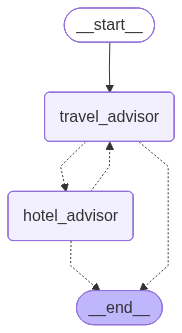

In [67]:
app = graph_builder.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [68]:
app.invoke({"messages":[("user","I am planning a trip to the Texas in the USA from Karachi. Can you guide me on travel options and suggest the best hotel?")]})

{'messages': [HumanMessage(content='I am planning a trip to the Texas in the USA from Karachi. Can you guide me on travel options and suggest the best hotel?', additional_kwargs={}, response_metadata={}, id='50dca5b3-aece-45b0-9e54-5e4c7a2d6fc6'),
  AIMessage(content="To travel from Karachi to Texas, you have several options. The most convenient way would be to fly. You can fly from Karachi's Jinnah International Airport (KHI) to one of the major airports in Texas, such as Dallas/Fort Worth International Airport (DFW) or George Bush Intercontinental Airport (IAH) in Houston.\n\nAs for the best hotel, I can suggest a few options, but for more tailored advice, I would recommend asking a hotel advisor. \n\n", additional_kwargs={'tool_calls': [{'id': '9jz523k6h', 'function': {'arguments': '{}', 'name': 'transfer_to_hotel_advisor'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 272, 'total_tokens': 383, 'completion_time': 0.348859923, '

In [70]:
for chunk in app.stream(
    {"messages": [("user", "I am planning a trip to the Texas in the USA from Karachi. Can you guide me on travel options and suggest the best hotel?")]},
):
    print("****chunk****")

    pretty_print_messsages(chunk)

****chunk****
Update from node travel_advisor:


================================== Ai Message ==================================

To travel from Karachi to Texas, you have several options. The most convenient way would be to fly. You can fly from Jinnah International Airport (KHI) in Karachi to one of the two major airports in Texas: Dallas/Fort Worth International Airport (DFW) or George Bush Intercontinental Airport (IAH) in Houston. 

There are no direct flights available from Karachi to Texas, so you will have to book a flight with one or more stops. Several airlines, such as Emirates, Qatar Airways, and Turkish Airlines, offer flights from Karachi to Texas with layovers in their respective hub cities.

Once you arrive in Texas, you can rent a car, use public transportation, or book a taxi/ride-hailing service to get to your destination.

As for hotel recommendations, I can suggest asking a hotel advisor for help.
Tool Calls:
  transfer_to_hotel_advisor (w1m4xrra9)
 Call ID: w1m4x

In [71]:
for chunk in app.stream(
    {"messages": [("user", "What are the best flight options from Karachi to Texas, and can you recommend top hotels for a comfortable and convenient stay?")]},
):
    print("****chunk****")

    pretty_print_messsages(chunk)

****chunk****
Update from node travel_advisor:


================================== Ai Message ==================================

To find the best flight options from Karachi to Texas, I can look up real-time information. For hotel recommendations, I'll ask the hotel advisor for help.
Tool Calls:
  transfer_to_hotel_advisor (esfxvaqs9)
 Call ID: esfxvaqs9
  Args:
================================= Tool Message =================================

Successfully transferred


****chunk****
Update from node hotel_advisor:


================================== Ai Message ==================================

I'm happy to help you with your query. However, I must point out that you initially asked about flight options from Karachi to Texas and hotel recommendations. Since I'm a hotel expert, I can provide you with some top hotel recommendations for a comfortable and convenient stay in Texas.

Some popular hotels in Texas include:

1. The Ritz-Carlton, Dallas
2. The St. Regis Houston
3. Four Seaso